<a href="https://colab.research.google.com/github/MinhThien1st/Deep_Learning_Course/blob/main/Lab02/DeepLearning_Lab02.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error

In [2]:
url = "https://raw.githubusercontent.com/huynhhoc/DataAnalystDeepLearning/refs/heads/main/Data/23_HOMES.csv"

df = pd.read_csv(url)

In [3]:
df.head()

,Selling_Price,List_Price,Area,Acres,Age,Taxes,Rooms,Bedrooms,Baths_full
0,400000,414000,2704,2.27,27,4920,9,3,3
1,370000,379000,2096,0.75,21,4113,8,4,2
2,382500,389900,2737,1.00,36,6072,9,4,2
3,300000,299900,1800,0.43,34,4024,8,4,2
4,305000,319900,1066,3.60,69,3562,6,3,2


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40 entries, 0 to 39
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Selling_Price  40 non-null     int64  
 1   List_Price     40 non-null     int64  
 2   Area           40 non-null     int64  
 3   Acres          40 non-null     float64
 4   Age            40 non-null     int64  
 5   Taxes          40 non-null     int64  
 6   Rooms          40 non-null     int64  
 7   Bedrooms       40 non-null     int64  
 8   Baths_full     40 non-null     int64  
dtypes: float64(1), int64(8)
memory usage: 2.9 KB


In [5]:
df.describe()

,Selling_Price,List_Price,Area,Acres,Age,Taxes,Rooms,Bedrooms,Baths_full
count,40.000000,40.000000,40.000000,40.000000,40.000000,40.000000,40.000000,40.000000,40.000000
mean,342672.500000,349937.500000,2058.375000,1.690250,38.125000,4626.625000,7.675000,3.300000,1.900000
std,83236.659784,84592.348831,657.934674,2.007324,22.944959,1848.538947,1.654636,0.723241,0.744208
min,210000.000000,219900.000000,1066.000000,0.250000,6.000000,1367.000000,4.000000,2.000000,1.000000
25%,292000.000000,294975.000000,1646.250000,0.667500,24.750000,3479.750000,6.000000,3.000000,1.000000
50%,309000.000000,319900.000000,1855.000000,1.000000,35.500000,4129.500000,8.000000,3.000000,2.000000
75%,388750.000000,395925.000000,2412.000000,1.880000,46.250000,5530.250000,9.000000,4.000000,2.000000
max,520000.000000,529700.000000,3867.000000,11.580000,144.000000,9809.000000,11.000000,5.000000,4.000000


In [6]:
df.isnull().sum()

,0
Selling_Price,0
List_Price,0
Area,0
Acres,0
Age,0
Taxes,0
Rooms,0
Bedrooms,0
Baths_full,0


In [7]:
X = df.drop(columns=["Selling_Price"])

y = df["Selling_Price"]

In [8]:
scaler = MinMaxScaler()

X_scaled = scaler.fit_transform(X)

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42
)

In [10]:
model = tf.keras.Sequential([

    tf.keras.layers.Dense(
        64,
        activation='relu',
        input_shape=(X_train.shape[1],)
    ),

    tf.keras.layers.Dense(
        32,
        activation='relu'
    ),

    tf.keras.layers.Dense(
        1
    )
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [11]:
model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

In [12]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           576 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,689 (10.50 KB)

 Trainable params: 2,689 (10.50 KB)

 Non-trainable params: 0 (0.00 B)

In [13]:
history = model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=8,
    verbose=1
)

Epoch 1/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 74ms/step - loss: 126226989056.0000 - mae: 347339.9062 - val_loss: 109672751104.0000 - val_mae: 316414.1562
Epoch 2/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 126226915328.0000 - mae: 347339.8125 - val_loss: 109672685568.0000 - val_mae: 316414.0312
Epoch 3/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 126226841600.0000 - mae: 347339.7188 - val_loss: 109672620032.0000 - val_mae: 316413.9688
Epoch 4/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 126226751488.0000 - mae: 347339.5625 - val_loss: 109672538112.0000 - val_mae: 316413.8438
Epoch 5/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 126226669568.0000 - mae: 347339.4375 - val_loss: 109672456192.0000 - val_mae: 316413.7500
Epoch 6/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 126226571264.0000 - mae: 347339.3125 - val_loss: 109672374272.0000 - val_mae: 316413.5938
Epoch 7/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 126226456576.0000 - mae: 347339.1562 - val_loss: 10967

In [14]:
loss, mae = model.evaluate(X_test, y_test)

print("Loss:", loss)
print("MAE:", mae)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step - loss: 129843568640.0000 - mae: 350204.1875
Loss: 129843568640.0
MAE: 350204.1875


In [15]:
predictions = model.predict(X_test)

print(predictions[:5])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step
[[ 558.161  ]
 [ 742.4958 ]
 [1186.3324 ]
 [1010.1194 ]
 [ 753.74524]]


In [16]:
comparison = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": predictions.flatten()
})

comparison.head()

,Actual,Predicted
0,272500,558.161011
1,280000,742.495789
2,475000,1186.332397
3,499000,1010.119385
4,305000,753.745239


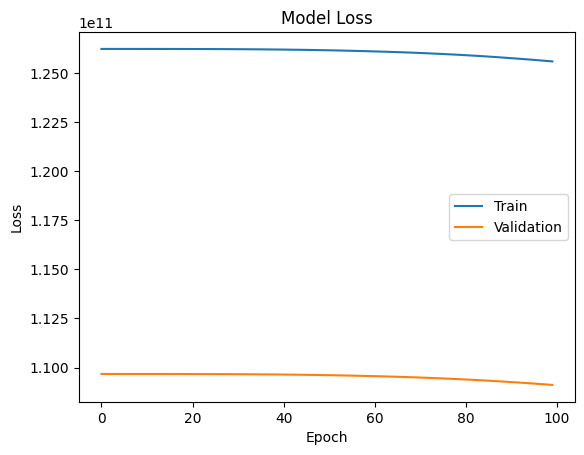

In [17]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend(['Train', 'Validation'])

plt.show()

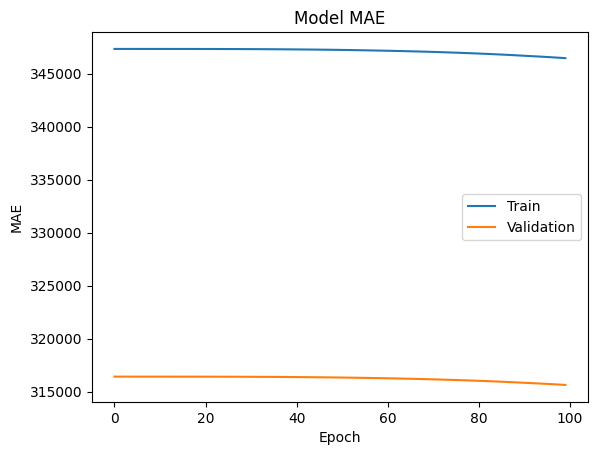

In [18]:
plt.plot(history.history['mae'])
plt.plot(history.history['val_mae'])

plt.title("Model MAE")
plt.xlabel("Epoch")
plt.ylabel("MAE")

plt.legend(['Train', 'Validation'])

plt.show()

In [19]:
model.save("house_price_ann.h5")

In [20]:
from google.colab import files

files.download("house_price_ann.h5")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>